# Reading Excel Files into R

Excel is everywhere in environmental work. Agencies report data in `.xlsx` files, collaborators share spreadsheets, and field data often lands in Excel first. Knowing how to read those files cleanly into R is an essential skill.

This lecture covers:

1. **Reading a single sheet** from an Excel file.
2. **Listing and reading multiple sheets** — how to handle a workbook with several tabs.
3. **Reading a report-style sheet** — where rows are labels, not observations, and the data does not start on row 1.
4. **Dealing with merged cells** — a common formatting pattern that breaks tidy reading.
5. **What is tidy data?** — and why it matters for analysis.

We will work with a sample deforestation dataset (`deforestation_example.xlsx`) that has three sheets designed to illustrate each challenge.

In [1]:
# -------------------------------------------------------------------------
# Housekeeping: install packages if needed, then load
# -------------------------------------------------------------------------
if (!require(readxl))  install.packages("readxl")
if (!require(dplyr))   install.packages("dplyr")
if (!require(tidyr))   install.packages("tidyr")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(janitor)) install.packages("janitor")

suppressPackageStartupMessages({
  library(readxl)  # for reading in excel data 
  library(dplyr)   # data plyrs
  library(tidyr)   # tidy data 
  library(ggplot2) # plotting
  library(janitor) # cleaning "dirty" data, especially columns
  library(readr)   # helpful functions for cleaning data "found in the wild" 
})

Loading required package: readxl

Loading required package: dplyr


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: ggplot2

Loading required package: janitor


Attaching package: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test




# 1. The Excel File We Are Working With

Before reading anything, it is good practice to inspect the workbook: how many sheets are there, and what are they called? `readxl` gives us `excel_sheets()` for exactly this.

In [2]:
# Path to the sample Excel file
path <- "deforestation_example.xlsx"

# List all sheet names
excel_sheets(path)

[1] "deforestation_tidy" "annual_report"      "merged_cells"

Three sheets:
- `deforestation_tidy` — data in a clean, analysis-ready format.
- `annual_report` — a formatted report where the first several rows are titles and metadata, not data.
- `merged_cells` — a sheet where the region column has merged cells spanning multiple rows.

Let's tackle each one.

# 2. Reading a Single Sheet

The workhorse function is `read_excel()`. At its simplest you just give it the file path. By default it reads the first sheet.

In [3]:
# -------------------------------------------------------------------------
# Read the first (tidy) sheet
# By default: sheet = 1, col_names = TRUE, skip = 0
# -------------------------------------------------------------------------
df_tidy <- read_excel(path, sheet = "deforestation_tidy")

df_tidy

country,year,forest_loss_km2,primary_forest
<chr>,<dbl>,<dbl>,<lgl>
Brazil,2018,7536,TRUE
Brazil,2019,10129,TRUE
Brazil,2020,11088,TRUE
Indonesia,2018,4916,FALSE
Indonesia,2019,6589,FALSE
Indonesia,2020,7354,FALSE
DRC,2018,1345,TRUE
DRC,2019,1900,TRUE
DRC,2020,2100,TRUE


In [4]:
# Check structure
glimpse(df_tidy)

Rows: 9
Columns: 4
$ country         <chr> "Brazil", "Brazil", "Brazil", "Indonesia", "Indonesia"~
$ year            <dbl> 2018, 2019, 2020, 2018, 2019, 2020, 2018, 2019, 2020
$ forest_loss_km2 <dbl> 7536, 10129, 11088, 4916, 6589, 7354, 1345, 1900, 2100
$ primary_forest  <lgl> TRUE, TRUE, TRUE, FALSE, FALSE, FALSE, TRUE, TRUE, TRUE


Notice that `readxl` correctly inferred the column types — `country` is a character, `year` is a number, `forest_loss_km2` is a number, and `primary_forest` is a logical (TRUE/FALSE). This is one of the big advantages over reading a CSV exported from Excel, where type inference can go wrong.

You can also refer to a sheet by its position number instead of its name:

```r
read_excel(path, sheet = 1)  # same result
```

## Quick Plot

Let's do a quick sanity check on the data before moving on.

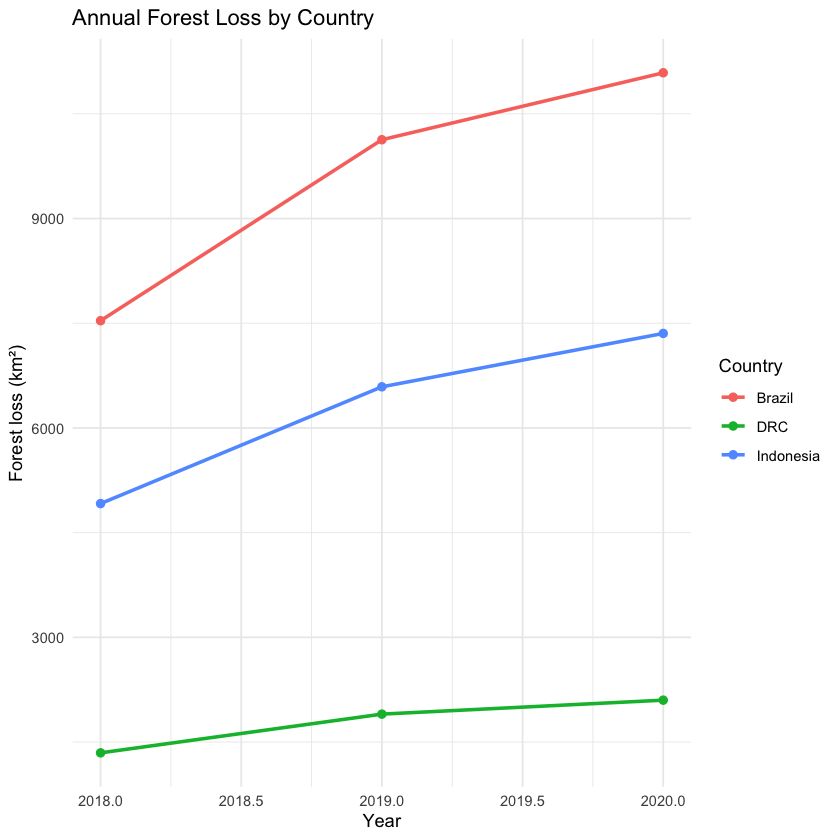

In [5]:
ggplot(df_tidy, aes(x = year, y = forest_loss_km2, color = country)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title  = "Annual Forest Loss by Country",
    x      = "Year",
    y      = "Forest loss (km\u00b2)",
    color  = "Country"
  ) +
  theme_minimal()

# 3. Reading a Report-Style Sheet

Real-world Excel files are often formatted for human readers, not computers. The `annual_report` sheet in our workbook looks like this when you open it:

| Row | Content |
|-----|---------|
| 1 | **Global Deforestation Summary Report** *(title)* |
| 2 | Prepared by: Forest Watch ... Date: 2021-01-15 |
| 3 | *(blank)* |
| 4 | **Region \| 2018 Loss \| 2019 Loss \| 2020 Loss** *(actual column headers)* |
| 5–7 | data rows |
| 8 | *(blank)* |
| 9–10 | footnotes |

If we read this naively, R will treat row 1 (the title) as the column headers and everything else as data — a mess. The fix is the `skip` argument.

In [6]:
# -------------------------------------------------------------------------
# Naive read — what goes wrong
# -------------------------------------------------------------------------
df_report_bad <- read_excel(path, sheet = "annual_report")
df_report_bad

New names:
* `` -> `...2`
* `` -> `...3`
* `` -> `...4`


Global Deforestation Summary Report,...2,...3,...4
<chr>,<chr>,<chr>,<chr>
Prepared by: Andie LLC,NA,Date:,2021-01-15
NA,NA,NA,NA
Region,2018 Loss (km2),2019 Loss (km2),2020 Loss (km2)
South America,7536,10129,11088
Southeast Asia,4916,6589,7354
Central Africa,1345,1900,2100
NA,NA,NA,NA
Source: Made up,NA,NA,NA
Note: you might have more details in a note,NA,NA,NA


R treated the title row as column names and made a mess of everything else. The fix is to tell `read_excel()` exactly where the real data starts.

Two useful arguments:
- **`skip`** — skip this many rows before reading. Use when the header row comes right after the junk rows.
- **`n_max`** — only read this many rows of data. Use to stop before footer footnotes at the bottom.

In [7]:
# -------------------------------------------------------------------------
# Clean read: skip the 3 header/title rows, stop before the footnotes
# Row 4 becomes the column header row, rows 5-7 are data
# -------------------------------------------------------------------------
df_report <- read_excel(
  path,
  sheet = "annual_report",
  skip  = 3,     # skip rows 1-3 (title, metadata, blank)
  n_max = 3      # read only 3 data rows (stop before the blank + footnotes)
)

df_report

Region,2018 Loss (km2),2019 Loss (km2),2020 Loss (km2)
<chr>,<dbl>,<dbl>,<dbl>
South America,7536,10129,11088
Southeast Asia,4916,6589,7354
Central Africa,1345,1900,2100


In [8]:
# Clean up column names to be R-friendly (lowercase, underscores)
df_report <- df_report %>%
  clean_names() # from the janitor package

df_report

Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00C4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00D6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00DC>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00E4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00F6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00FC>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00DF>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00C6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00E6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00D8>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00F8>' to native encoding"
Warning message in FU

region,x2018_loss_km2,x2019_loss_km2,x2020_loss_km2
<chr>,<dbl>,<dbl>,<dbl>
South America,7536,10129,11088
Southeast Asia,4916,6589,7354
Central Africa,1345,1900,2100


# 4. Dealing With Merged Cells

Merged cells are a common Excel formatting pattern — especially in region or category columns where the same label applies to several rows. When R reads a merged cell, it only sees the value in the **top-left cell** of the merged range; the rest come in as `NA`.

Our `merged_cells` sheet has the region column merged across three rows per region.

In [9]:
# -------------------------------------------------------------------------
# Read the merged-cells sheet
# -------------------------------------------------------------------------
df_merged <- read_excel(path, sheet = "merged_cells")

df_merged

Region,Country,Year,Forest Loss (km2)
<chr>,<chr>,<dbl>,<dbl>
South America,Brazil,2018,7536
NA,Brazil,2019,10129
NA,Brazil,2020,11088
Southeast Asia,Indonesia,2018,4916
NA,Indonesia,2019,6589
NA,Indonesia,2020,7354


The `Region` column has values only in the first row of each group — the merged rows read as `NA`. The fix is `fill()` from the `tidyr` package. It fills `NA` values downward with the last non-missing value above.

In [10]:
# -------------------------------------------------------------------------
# Fix merged cells: fill NAs downward
# -------------------------------------------------------------------------
df_merged_clean <- df_merged %>%
  fill(Region, .direction = "down") # from tidyr package

df_merged_clean

Region,Country,Year,Forest Loss (km2)
<chr>,<chr>,<dbl>,<dbl>
South America,Brazil,2018,7536
South America,Brazil,2019,10129
South America,Brazil,2020,11088
Southeast Asia,Indonesia,2018,4916
Southeast Asia,Indonesia,2019,6589
Southeast Asia,Indonesia,2020,7354


Now every row has the region it belongs to. This two-step pattern — `read_excel()` then `fill()` — handles the vast majority of merged-cell situations you will encounter in the wild.

# 5. What Is Tidy Data?

Now that we have seen both well-structured and messy Excel files, it is worth defining what we are always trying to arrive at: **tidy data**.

Tidy data has three rules (Hadley Wickham, 2014):

1. **Every column is a variable.** Each thing you measured or recorded gets its own column.
2. **Every row is an observation.** Each row represents one unit of data (one country-year, one species sighting, one water sample).
3. **Every cell is a single value.** No combining two pieces of information in one cell.

## Why does it matter?

Every `dplyr`, `ggplot2`, and statistical modeling function in R is designed to work with tidy data. When your data is tidy, one line of code does what would otherwise take twenty.

## A quick comparison

| Format | What it looks like | Tidy? |
|--------|--------------------|-------|
| One row per country-year, one column per variable | `country, year, forest_loss_km2` | ✅ Yes |
| One row per region, separate columns for each year | `region, loss_2018, loss_2019, loss_2020` | ❌ No, but almost — year is a variable, not a column name |
| Title rows, blank rows, footnotes mixed in | The `annual_report` sheet | ❌ No |
| Merged cells | The `merged_cells` sheet before `fill()` | ❌ No |

The `annual_report` sheet is a great example of data formatted for **presentation** rather than **analysis**. It looks professional in a PDF. But R cannot work with it until we strip away the report formatting and get back to one-row-per-observation.

## The wide-to-long pivot

One of the most common untidy patterns is the **wide format** — where a variable (like year) is spread across multiple column names. The `df_report` sheet we cleaned earlier is a good example. Let's pivot it to tidy (long) format using `pivot_longer()`.

In [11]:
# -------------------------------------------------------------------------
# df_report is currently WIDE: one column per year
# Pivot to LONG (tidy): one row per region-year
# -------------------------------------------------------------------------
df_report_tidy <- df_report %>%
  pivot_longer(
    cols      = -region,           # pivot everything except the region column
    names_to  = "year",            # column names become values in this column
    values_to = "forest_loss_km2"  # cell values go here
  ) %>%
  mutate(year = parse_number(year))  # strip the label text, keep just the number (e.g. 2018)

df_report_tidy

region,year,forest_loss_km2
<chr>,<dbl>,<dbl>
South America,2018,7536
South America,2019,10129
South America,2020,11088
Southeast Asia,2018,4916
Southeast Asia,2019,6589
Southeast Asia,2020,7354
Central Africa,2018,1345
Central Africa,2019,1900
Central Africa,2020,2100


Now the data follows all three tidy rules:
- Each column is one variable (`region`, `year`, `forest_loss_km2`).
- Each row is one observation (one region in one year).
- Each cell holds one value.

`parse_number()` from `readr` is a handy utility that extracts the first number it finds in a string — so whether `clean_names()` turned your column into `x2018_loss_km2` or something else, `parse_number()` will reliably pull out `2018`.

From here you can filter, group, summarise, join to other datasets, or plot — all with the standard tidyverse tools you are learning.

---

**Key takeaways from this lecture:**
- Use `excel_sheets()` to inspect a workbook before reading it.
- Use `skip` and `n_max` in `read_excel()` to navigate around report-style formatting.
- Use `fill()` from `tidyr` to repair columns with merged cells.
- Use `parse_number()` after `pivot_longer()` to clean up year (or other numeric) column names that picked up extra text.
- Always aim for tidy data: one variable per column, one observation per row, one value per cell.